Linearity (R-squared): 0.0008


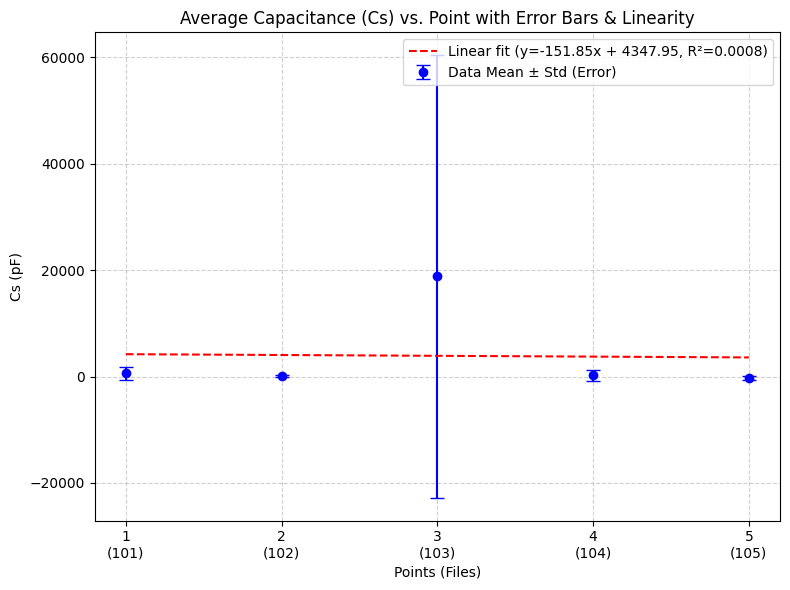

In [3]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            # ใช้ skiprows=4 เพื่อข้ามบรรทัด Header ตั้งค่าของเครื่องมือวัด (เริ่มต้นอ่านที่ชื่อคอลัมน์)
            dfs[it["name"]] = pd.read_csv(url, skiprows=4)
            
            # ลบ Space ว่างที่ติดมากับชื่อคอลัมน์ เช่น ' Cs(F)-data' จะกลายเป็น 'Cs(F)-data'
            dfs[it["name"]].columns = dfs[it["name"]].columns.str.strip()
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# การเรียกใช้งานไฟล์จาก GitHub ตามโครงสร้างจริงของคุณ
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
subfolder = "FirstDataset/02"
dataframes = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

# สร้างลิสต์ของชื่อไฟล์เพื่อให้ตรงกับจุดที่ต้องการ (1 ถึง 5)
sorted_files = ["101.CSV", "102.CSV", "103.CSV", "104.CSV", "105.CSV"]
x_values = []
y_means = []
y_errs = []

# ดึงข้อมูลจาก DataFrames มาคำนวณค่าเฉลี่ยและ Error (Standard Deviation)
for i, f in enumerate(sorted_files):
    if f in dataframes:
        x_val = i + 1
        x_values.append(x_val)
        
        # ปรับหน่วยจาก Farad เป็น picoFarad (pF) โดยการคูณ 1e12 
        # (เพราะค่าที่ได้มาอยู่ในระดับ e-10 ถึง e-12)
        mean_val = dataframes[f]['Cs(F)-data'].mean() * 1e12
        std_val = dataframes[f]['Cs(F)-data'].std() * 1e12
        
        y_means.append(mean_val)
        y_errs.append(std_val)

# หาค่า Linearity ด้วยสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_means)
r_squared = r_value**2

print(f"Linearity (R-squared): {r_squared:.4f}")

# วาดกราฟ
fig, ax = plt.subplots(figsize=(8, 6))

# พล็อตกราฟค่าเฉลี่ยและใส่ Error bars
ax.errorbar(x_values, y_means, yerr=y_errs, fmt='o', capsize=5, color='blue', label='Data Mean ± Std (Error)')

# พล็อตเส้นแนวโน้ม (Linear Regression line)
trendline = [slope * x + intercept for x in x_values]
ax.plot(x_values, trendline, 'r--', label=f'Linear fit (y={slope:.2f}x + {intercept:.2f}, R²={r_squared:.4f})')

# ตั้งค่าแกน X ตามเงื่อนไขที่คุณต้องการ (จุด 1 คือ 101, ฯลฯ)
ax.set_xticks(x_values)
ax.set_xticklabels(['1\n(101)', '2\n(102)', '3\n(103)', '4\n(104)', '5\n(105)'])
ax.set_xlabel('Points (Files)')
ax.set_ylabel('Cs (pF)')
ax.set_title('Average Capacitance (Cs) vs. Point with Error Bars & Linearity')
ax.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()